# Exploratory Data Analysis — Onera Satellite Change Detection (Raw Data)

EDA on the **raw dataset** under `raw_data/` only (no project pipeline code).

**How to run:** `Kernel → Restart & Run All`. Keep `CFG["fast_mode"] = False` for full results; set `True` for a quicker pass (~2 min).

| Section | Contents |
|---------|----------|
| 0 | Config, paths, helpers |
| 1 | Dataset overview |
| 2 | Resolution analysis |
| 3 | Band-level statistics |
| 4 | Pixel-level & spectral indices |
| 5 | Class balance |
| 6 | Feature importance |
| 7 | Visual samples & spatial patches |
| 8 | Interpretation & next-step roadmap |
| 9 | Key takeaways |


In [23]:

# ── Configuration ──────────────────────────────────────────────────────────
CFG = {
    "fast_mode": False,          # True → fewer cities / smaller samples (~2 min total)
    "example_city": "paris",     # reference city for resolution deep-dive
    "sample_city": "paris",      # city for histogram panels
    "visual_cities": ["paris", "beirut", "bercy"],
    "random_seed": 42,
}
CFG["pixels_per_class"] = 1500 if CFG["fast_mode"] else 3000   # per city, per class
CFG["band_stats_cities"] = None   # None = all train cities
CFG["corr_cities"] = 4 if CFG["fast_mode"] else 8
CFG["rf_estimators"] = 100 if CFG["fast_mode"] else 200
CFG


{'fast_mode': False,
 'example_city': 'paris',
 'sample_city': 'paris',
 'visual_cities': ['paris', 'beirut', 'bercy'],
 'random_seed': 42,
 'pixels_per_class': 3000,
 'band_stats_cities': None,
 'corr_cities': 8,
 'rf_estimators': 200}

In [24]:

from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import rasterio
from scipy import stats
from scipy.ndimage import label as cc_label
from tqdm.auto import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)
%matplotlib inline

# Resolve project root whether the notebook cwd is notebooks/ or repo root
_candidates = [Path.cwd(), Path.cwd().parent, Path("..").resolve(), Path(".").resolve()]
PROJECT_ROOT = next(
    (p for p in _candidates if (p / "raw_data/images").exists()),
    Path("..").resolve(),
)
IMAGES_ROOT = PROJECT_ROOT / "raw_data/images/Onera Satellite Change Detection dataset - Images"
LABELS_ROOT = PROJECT_ROOT / "raw_data/train_labels/Onera Satellite Change Detection dataset - Train Labels"

for name, path in [("images", IMAGES_ROOT), ("labels", LABELS_ROOT)]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {name} at {path}. cwd={Path.cwd()}  root={PROJECT_ROOT}")

BANDS = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B10", "B11", "B12"]
BAND_RESOLUTION_M = {
    "B01": 60, "B02": 10, "B03": 10, "B04": 10,
    "B05": 20, "B06": 20, "B07": 20, "B08": 10,
    "B8A": 20, "B09": 60, "B10": 60, "B11": 20, "B12": 20,
}
BAND_DESCRIPTIONS = {
    "B01": "Coastal aerosol (443 nm)", "B02": "Blue (490 nm)", "B03": "Green (560 nm)",
    "B04": "Red (665 nm)", "B05": "Red edge (705 nm)", "B06": "Red edge (740 nm)",
    "B07": "Red edge (783 nm)", "B08": "NIR (842 nm)", "B8A": "Narrow NIR (865 nm)",
    "B09": "Water vapour (945 nm)", "B10": "Cirrus (1375 nm)",
    "B11": "SWIR (1610 nm)", "B12": "SWIR (2190 nm)",
}
FEATURE_NAMES = [f"|Δ{band}|" for band in BANDS] + ["|ΔNDVI|", "|ΔNDWI|", "|ΔNDBI|"]
RNG = np.random.default_rng(CFG["random_seed"])

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 5), "font.size": 10})
print(f"Project root : {PROJECT_ROOT}")
print(f"Fast mode    : {CFG['fast_mode']}")


Project root : /Users/asifh1/Desktop/Summer'26/Niels Bohr Summer School/Student Challenge/Pipeline Cursor
Fast mode    : False


In [25]:

def list_cities(root: Path) -> list[str]:
    return sorted(d.name for d in root.iterdir() if d.is_dir() and not d.name.startswith("."))


def read_split(filename: str) -> list[str]:
    return [c.strip() for c in (IMAGES_ROOT / filename).read_text().split(",") if c.strip()]


def find_native_band_file(folder: Path, band: str) -> Path:
    matches = sorted(folder.glob(f"*{band}.tif"))
    if not matches:
        raise FileNotFoundError(f"No {band} tif in {folder}")
    return matches[0]


def load_rect_stack(city: str, era: str) -> np.ndarray:
    folder = IMAGES_ROOT / city / era
    planes = []
    for band in BANDS:
        with rasterio.open(folder / f"{band}.tif") as src:
            planes.append(src.read(1).astype(np.float32))
    return np.stack(planes, axis=0)


def load_label(city: str) -> np.ndarray:
    tif_path = LABELS_ROOT / city / "cm" / f"{city}-cm.tif"
    if not tif_path.exists():
        raise FileNotFoundError(f"No label for {city}: {tif_path}")
    with rasterio.open(tif_path) as src:
        return src.read(1)


def label_to_binary(label: np.ndarray) -> np.ndarray:
    uniq = set(np.unique(label).tolist())
    if uniq <= {0, 1}:
        return (label == 1).astype(np.uint8)
    if uniq <= {1, 2}:
        return (label == 2).astype(np.uint8)
    raise ValueError(f"Unexpected label values: {sorted(uniq)}")


def compute_ndvi(red, nir):
    denom = red + nir
    return np.where(denom == 0, 0.0, (nir - red) / denom)


def compute_ndwi(green, nir):
    denom = green + nir
    return np.where(denom == 0, 0.0, (green - nir) / denom)


def compute_ndbi(swir, nir):
    denom = swir + nir
    return np.where(denom == 0, 0.0, (swir - nir) / denom)


def band_index(name: str) -> int:
    return BANDS.index(name)


def stratified_subsample(X, y, n_per_class, seed=42):
    rng = np.random.default_rng(seed)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        raise ValueError("Need both classes for subsampling")
    sel = np.concatenate([
        rng.choice(idx_pos, min(n_per_class, len(idx_pos)), replace=False),
        rng.choice(idx_neg, min(n_per_class, len(idx_neg)), replace=False),
    ])
    return X[sel], y[sel]


def build_pixel_features(city: str) -> tuple[np.ndarray, np.ndarray]:
    t1 = load_rect_stack(city, "imgs_1_rect")
    t2 = load_rect_stack(city, "imgs_2_rect")
    y = label_to_binary(load_label(city)).ravel()
    band_diff = np.abs(t2 - t1).reshape(len(BANDS), -1).T
    bi = {b: band_index(b) for b in ["B03", "B04", "B08", "B11"]}
    ndvi_d = np.abs(compute_ndvi(t2[bi["B04"]], t2[bi["B08"]]) - compute_ndvi(t1[bi["B04"]], t1[bi["B08"]])).ravel()
    ndwi_d = np.abs(compute_ndwi(t2[bi["B03"]], t2[bi["B08"]]) - compute_ndwi(t1[bi["B03"]], t1[bi["B08"]])).ravel()
    ndbi_d = np.abs(compute_ndbi(t2[bi["B11"]], t2[bi["B08"]]) - compute_ndbi(t1[bi["B11"]], t1[bi["B08"]])).ravel()
    return np.column_stack([band_diff, ndvi_d, ndwi_d, ndbi_d]), y


def rank_consensus(importance_df: pd.DataFrame, top_k: int = 6) -> pd.DataFrame:
    ranks = importance_df.copy()
    for col in ["point_biserial_r", "mutual_info", "rf_importance"]:
        ranks[f"{col}_rank"] = ranks[col].rank(ascending=False)
    ranks["consensus_rank"] = ranks[[
        "point_biserial_r_rank", "mutual_info_rank", "rf_importance_rank"
    ]].mean(axis=1)
    return ranks.sort_values("consensus_rank").head(top_k)


def normalize_rgb(stack, bands=("B04", "B03", "B02"), pct=(2, 98)):
    idx = [band_index(b) for b in bands]
    rgb = np.stack([stack[i] for i in idx], axis=-1).astype(np.float32)
    lo, hi = np.percentile(rgb, pct[0]), np.percentile(rgb, pct[1])
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)


ALL_CITIES = list_cities(IMAGES_ROOT)
TRAIN_CITIES = read_split("train.txt")
TEST_CITIES = read_split("test.txt")
assert set(TRAIN_CITIES) | set(TEST_CITIES) == set(ALL_CITIES)

print(f"Cities: {len(ALL_CITIES)} total | {len(TRAIN_CITIES)} train | {len(TEST_CITIES)} test")


Cities: 24 total | 14 train | 10 test


## 1. Dataset overview

Per-city metadata: dates, rectified dimensions, label availability.

In [26]:

overview_rows = []
for city in tqdm(ALL_CITIES, desc="Overview"):
    dates_path = IMAGES_ROOT / city / "dates.txt"
    dates = {}
    if dates_path.exists():
        for line in dates_path.read_text().strip().splitlines():
            k, v = line.split(":", 1)
            dates[k.strip()] = v.strip()
    with rasterio.open(IMAGES_ROOT / city / "imgs_1_rect" / "B02.tif") as src:
        h, w = src.height, src.width
    label_path = LABELS_ROOT / city / "cm" / f"{city}-cm.tif"
    overview_rows.append({
        "city": city,
        "split": "train" if city in TRAIN_CITIES else "test",
        "date_t1": dates.get("date_1", ""),
        "date_t2": dates.get("date_2", ""),
        "height_px": h, "width_px": w, "n_pixels": h * w,
        "has_label": label_path.exists(),
        "time_gap_days": (
            pd.to_datetime(dates["date_2"], format="%Y%m%d") - pd.to_datetime(dates["date_1"], format="%Y%m%d")
        ).days if {"date_1", "date_2"} <= dates.keys() else np.nan,
    })

overview_df = pd.DataFrame(overview_rows)
overview_df


Overview: 100%|██████████| 24/24 [00:00<00:00, 588.41it/s]


,city,split,date_t1,date_t2,height_px,width_px,n_pixels,has_label,time_gap_days
0,abudhabi,train,20160120,20180328,799,785,627215,True,798
1,aguasclaras,train,20150916,20171015,471,525,247275,True,760
2,beihai,train,20161209,20180309,902,772,696344,True,455
3,beirut,train,20150820,20171003,1180,1070,1262600,True,775
4,bercy,train,20161130,20170829,395,360,142200,True,272
5,bordeaux,train,20160504,20171026,517,461,238337,True,540
6,brasilia,test,20150916,20171017,433,469,203077,False,762
7,chongqing,test,20170414,20180402,730,544,397120,False,353
8,cupertino,train,20150918,20180326,1015,788,799820,True,920
9,dubai,test,20151211,20180330,774,634,490716,False,840


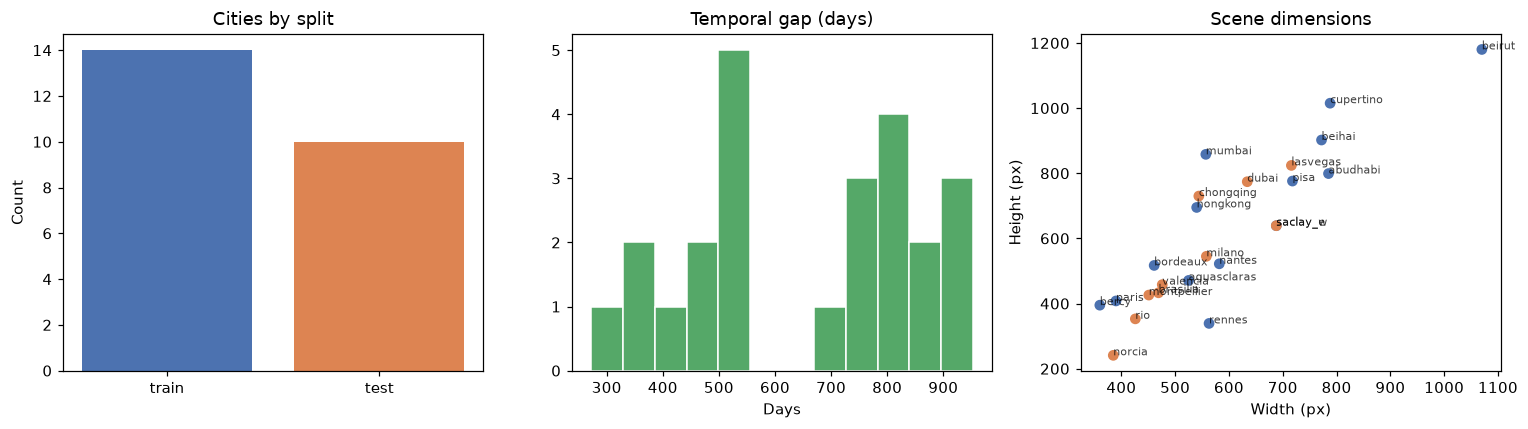

Train pixels: 6,517,578
Test pixels : 3,077,936


In [27]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
split_counts = overview_df["split"].value_counts()
axes[0].bar(split_counts.index, split_counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Cities by split"); axes[0].set_ylabel("Count")
axes[1].hist(overview_df["time_gap_days"].dropna(), bins=12, color="#55A868", edgecolor="white")
axes[1].set_title("Temporal gap (days)"); axes[1].set_xlabel("Days")
colors = overview_df["split"].map({"train": "#4C72B0", "test": "#DD8452"})
axes[2].scatter(overview_df["width_px"], overview_df["height_px"], c=colors)
for _, row in overview_df.iterrows():
    axes[2].annotate(row["city"], (row["width_px"], row["height_px"]), fontsize=7, alpha=0.75)
axes[2].set_xlabel("Width (px)"); axes[2].set_ylabel("Height (px)"); axes[2].set_title("Scene dimensions")
plt.tight_layout(); plt.show()
print(f"Train pixels: {overview_df.loc[overview_df['split']=='train','n_pixels'].sum():,}")
print(f"Test pixels : {overview_df.loc[overview_df['split']=='test','n_pixels'].sum():,}")


## 2. Spatial resolution analysis

Native Sentinel-2 bands are 10/20/60 m. `*_rect` folders resample to a common 10 m grid.

In [28]:

EXAMPLE_CITY = CFG["example_city"]
resolution_rows = []
for era in ["imgs_1", "imgs_2"]:
    folder = IMAGES_ROOT / EXAMPLE_CITY / era
    for band in BANDS:
        fp = find_native_band_file(folder, band)
        with rasterio.open(fp) as src:
            resolution_rows.append({
                "era": era, "band": band, "native_res_m": BAND_RESOLUTION_M[band],
                "height": src.height, "width": src.width,
                "crs": str(src.crs), "gsd_x": src.res[0], "gsd_y": src.res[1],
            })
res_df = pd.DataFrame(resolution_rows)
res_pivot = res_df[res_df["era"] == "imgs_1"].set_index("band")[["native_res_m", "height", "width"]]
res_pivot.index = [f"{b} — {BAND_DESCRIPTIONS[b]}" for b in res_pivot.index]
print(f"Native band metadata for {EXAMPLE_CITY}")
res_pivot


Native band metadata for paris


,native_res_m,height,width
B01 — Coastal aerosol (443 nm),60,68,65
B02 — Blue (490 nm),10,408,390
B03 — Green (560 nm),10,408,390
B04 — Red (665 nm),10,408,390
B05 — Red edge (705 nm),20,204,195
B06 — Red edge (740 nm),20,204,195
B07 — Red edge (783 nm),20,204,195
B08 — NIR (842 nm),10,408,390
B8A — Narrow NIR (865 nm),20,204,195
B09 — Water vapour (945 nm),60,68,65


In [29]:

shape_rows = []
for city in ALL_CITIES:
    native_fp = find_native_band_file(IMAGES_ROOT / city / "imgs_1", "B02")
    rect_fp = IMAGES_ROOT / city / "imgs_1_rect" / "B02.tif"
    with rasterio.open(native_fp) as n, rasterio.open(rect_fp) as r:
        shape_rows.append({
            "city": city,
            "native_h": n.height, "native_w": n.width,
            "rect_h": r.height, "rect_w": r.width,
            "same_shape": (n.height == r.height and n.width == r.width),
        })
shape_df = pd.DataFrame(shape_rows)
print(f"Native B02 == rectified shape: {shape_df['same_shape'].sum()} / {len(shape_df)} cities")

band_shape_rows = []
native_dir = IMAGES_ROOT / EXAMPLE_CITY / "imgs_1"
rect_dir = IMAGES_ROOT / EXAMPLE_CITY / "imgs_1_rect"
for band in BANDS:
    native_fp = find_native_band_file(native_dir, band)
    with rasterio.open(native_fp) as native, rasterio.open(rect_dir / f"{band}.tif") as rect:
        n_px, r_px = native.height * native.width, rect.height * rect.width
        band_shape_rows.append({
            "band": band, "native_res_m": BAND_RESOLUTION_M[band],
            "native_pixels": n_px, "rect_pixels": r_px,
            "upsample_factor": r_px / n_px if n_px else np.nan,
        })
band_shape_df = pd.DataFrame(band_shape_rows)
band_shape_df


Native B02 == rectified shape: 24 / 24 cities


,band,native_res_m,native_pixels,rect_pixels,upsample_factor
0,B01,60,4420,159120,36.0
1,B02,10,159120,159120,1.0
2,B03,10,159120,159120,1.0
3,B04,10,159120,159120,1.0
4,B05,20,39780,159120,4.0
5,B06,20,39780,159120,4.0
6,B07,20,39780,159120,4.0
7,B08,10,159120,159120,1.0
8,B8A,20,39780,159120,4.0
9,B09,60,4420,159120,36.0


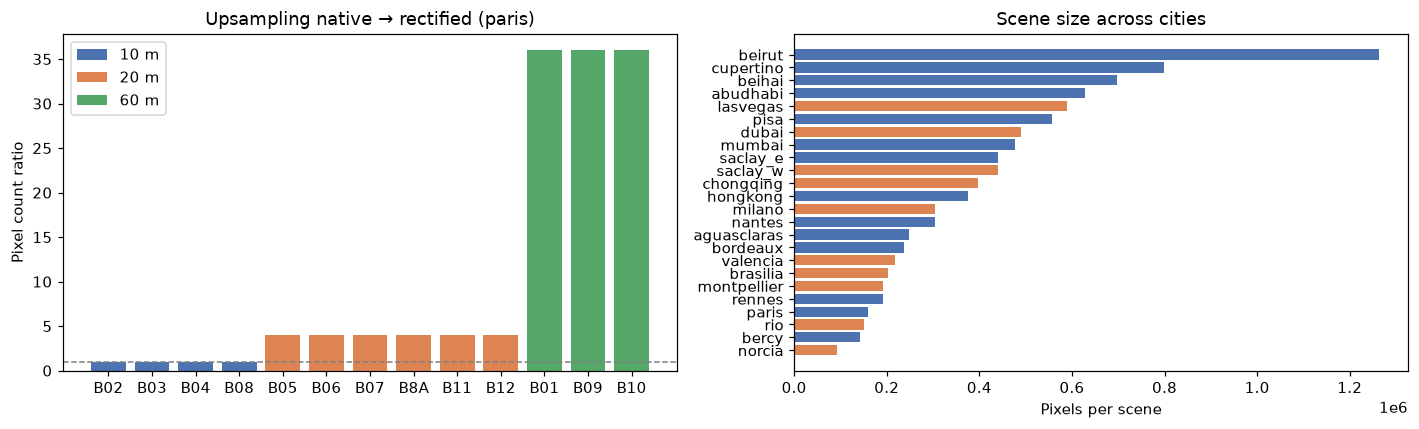

In [30]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
res_colors = {10: "#4C72B0", 20: "#DD8452", 60: "#55A868"}
for res_m in [10, 20, 60]:
    sub = band_shape_df[band_shape_df["native_res_m"] == res_m]
    axes[0].bar(sub["band"], sub["upsample_factor"], label=f"{res_m} m", color=res_colors[res_m])
axes[0].axhline(1.0, color="gray", ls="--", lw=1)
axes[0].set_title(f"Upsampling native → rectified ({EXAMPLE_CITY})")
axes[0].set_ylabel("Pixel count ratio"); axes[0].legend()
overview_sorted = overview_df.sort_values("n_pixels")
bar_colors = overview_sorted["split"].map({"train": "#4C72B0", "test": "#DD8452"})
axes[1].barh(overview_sorted["city"], overview_sorted["n_pixels"], color=bar_colors)
axes[1].set_xlabel("Pixels per scene"); axes[1].set_title("Scene size across cities")
plt.tight_layout(); plt.show()


## 3. Band-level statistics

Per-band reflectance and |t2 − t1| across train cities.

In [31]:

stats_cities = TRAIN_CITIES if CFG["band_stats_cities"] is None else CFG["band_stats_cities"]
band_stat_rows = []
for city in tqdm(stats_cities, desc="Band stats"):
    t1 = load_rect_stack(city, "imgs_1_rect")
    t2 = load_rect_stack(city, "imgs_2_rect")
    diff = np.abs(t2 - t1)
    for i, band in enumerate(BANDS):
        for era_name, arr in [("t1", t1[i]), ("t2", t2[i]), ("abs_diff", diff[i])]:
            band_stat_rows.append({
                "city": city, "band": band, "era": era_name,
                "mean": float(arr.mean()), "std": float(arr.std()),
                "median": float(np.median(arr)),
                "p25": float(np.percentile(arr, 25)), "p75": float(np.percentile(arr, 75)),
                "min": float(arr.min()), "max": float(arr.max()),
            })
band_stats_df = pd.DataFrame(band_stat_rows)
band_stats_df.head(8)


Band stats: 100%|██████████| 14/14 [00:05<00:00,  2.63it/s]


,city,band,era,mean,std,median,p25,p75,min,max
0,aguasclaras,B01,t1,1324.597778,152.996887,1320.0,1216.0,1415.0,994.0,2934.0
1,aguasclaras,B01,t2,1409.931030,178.164093,1401.0,1290.0,1511.0,1020.0,3243.0
2,aguasclaras,B01,abs_diff,88.440506,72.691093,76.0,50.0,109.0,0.0,2002.0
3,aguasclaras,B02,t1,1188.844971,297.554626,1139.0,1010.0,1292.0,747.0,8681.0
4,aguasclaras,B02,t2,1291.829468,357.013702,1236.0,1094.0,1399.0,406.0,13882.0
5,aguasclaras,B02,abs_diff,136.641449,209.666031,90.0,45.0,158.0,0.0,12830.0
6,aguasclaras,B03,t1,1216.289307,356.939423,1163.0,1002.0,1346.0,581.0,8794.0
7,aguasclaras,B03,t2,1349.773193,423.226654,1290.0,1111.0,1488.0,509.0,13097.0


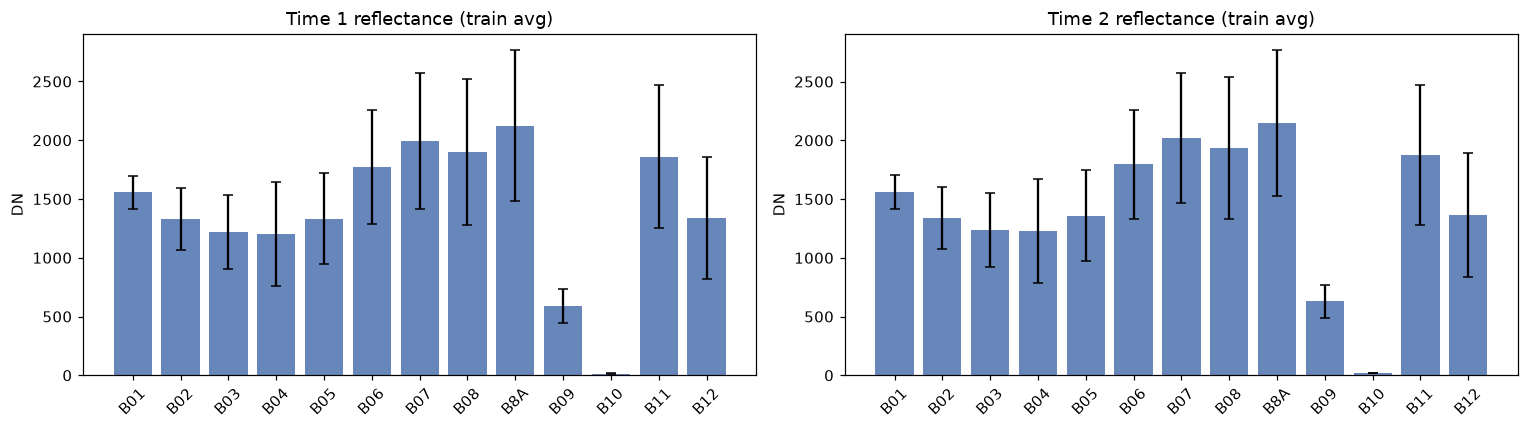

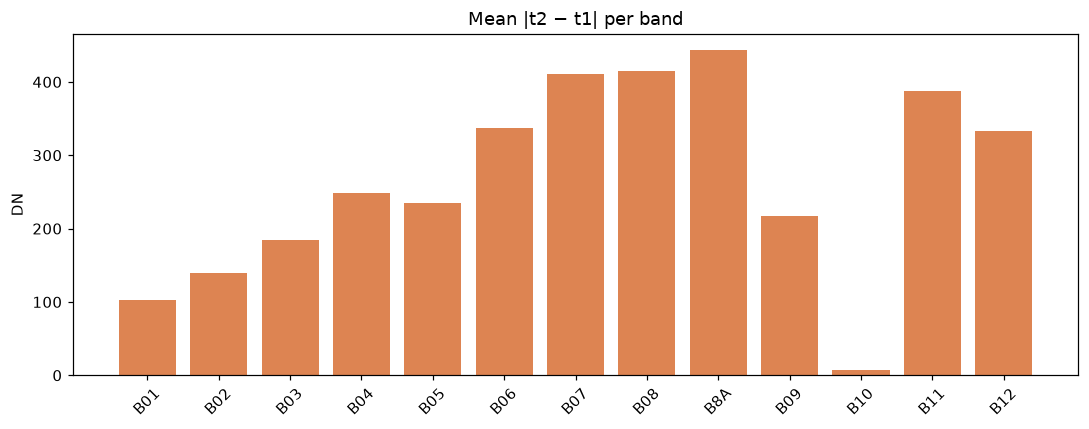

In [32]:

agg = band_stats_df.groupby(["band", "era"]).agg(mean=("mean", "mean"), std=("std", "mean")).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, era, title in zip(axes, ["t1", "t2"], ["Time 1 reflectance", "Time 2 reflectance"]):
    sub = agg[agg["era"] == era].set_index("band").loc[BANDS]
    ax.bar(sub.index, sub["mean"], yerr=sub["std"], capsize=3, color="#4C72B0", alpha=0.85)
    ax.set_title(f"{title} (train avg)"); ax.set_ylabel("DN"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

diff_agg = band_stats_df[band_stats_df["era"] == "abs_diff"].groupby("band")["mean"].mean().loc[BANDS]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(diff_agg.index, diff_agg.values, color="#DD8452")
ax.set_title("Mean |t2 − t1| per band"); ax.set_ylabel("DN"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


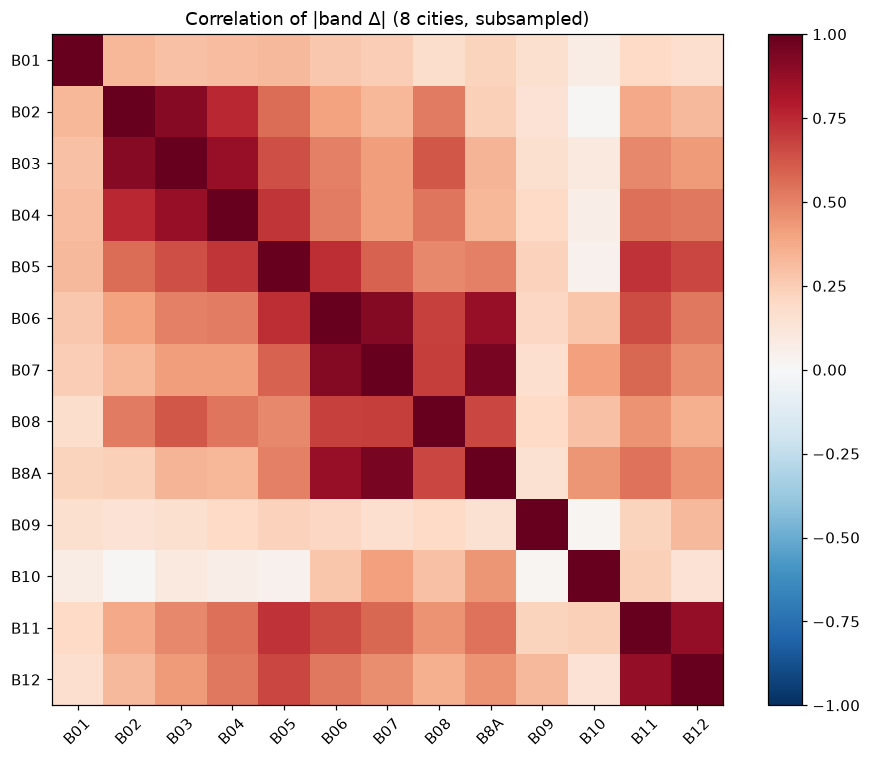

In [33]:

SUBSAMPLE = 40_000 if CFG["fast_mode"] else 80_000
corr_cities = TRAIN_CITIES[: CFG["corr_cities"]]
sample_features = []
per_city = max(SUBSAMPLE // len(corr_cities), 1000)
for city in corr_cities:
    t1 = load_rect_stack(city, "imgs_1_rect")
    t2 = load_rect_stack(city, "imgs_2_rect")
    diff = np.abs(t2 - t1).reshape(len(BANDS), -1).T
    idx = RNG.choice(diff.shape[0], size=min(per_city, diff.shape[0]), replace=False)
    sample_features.append(diff[idx])
X_corr = np.vstack(sample_features)
corr_matrix = np.corrcoef(X_corr.T)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(BANDS)), BANDS, rotation=45)
ax.set_yticks(range(len(BANDS)), BANDS)
ax.set_title(f"Correlation of |band Δ| ({len(corr_cities)} cities, subsampled)")
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()


## 4. Pixel-level analysis

DN distributions, change vs no-change profiles, spectral indices.

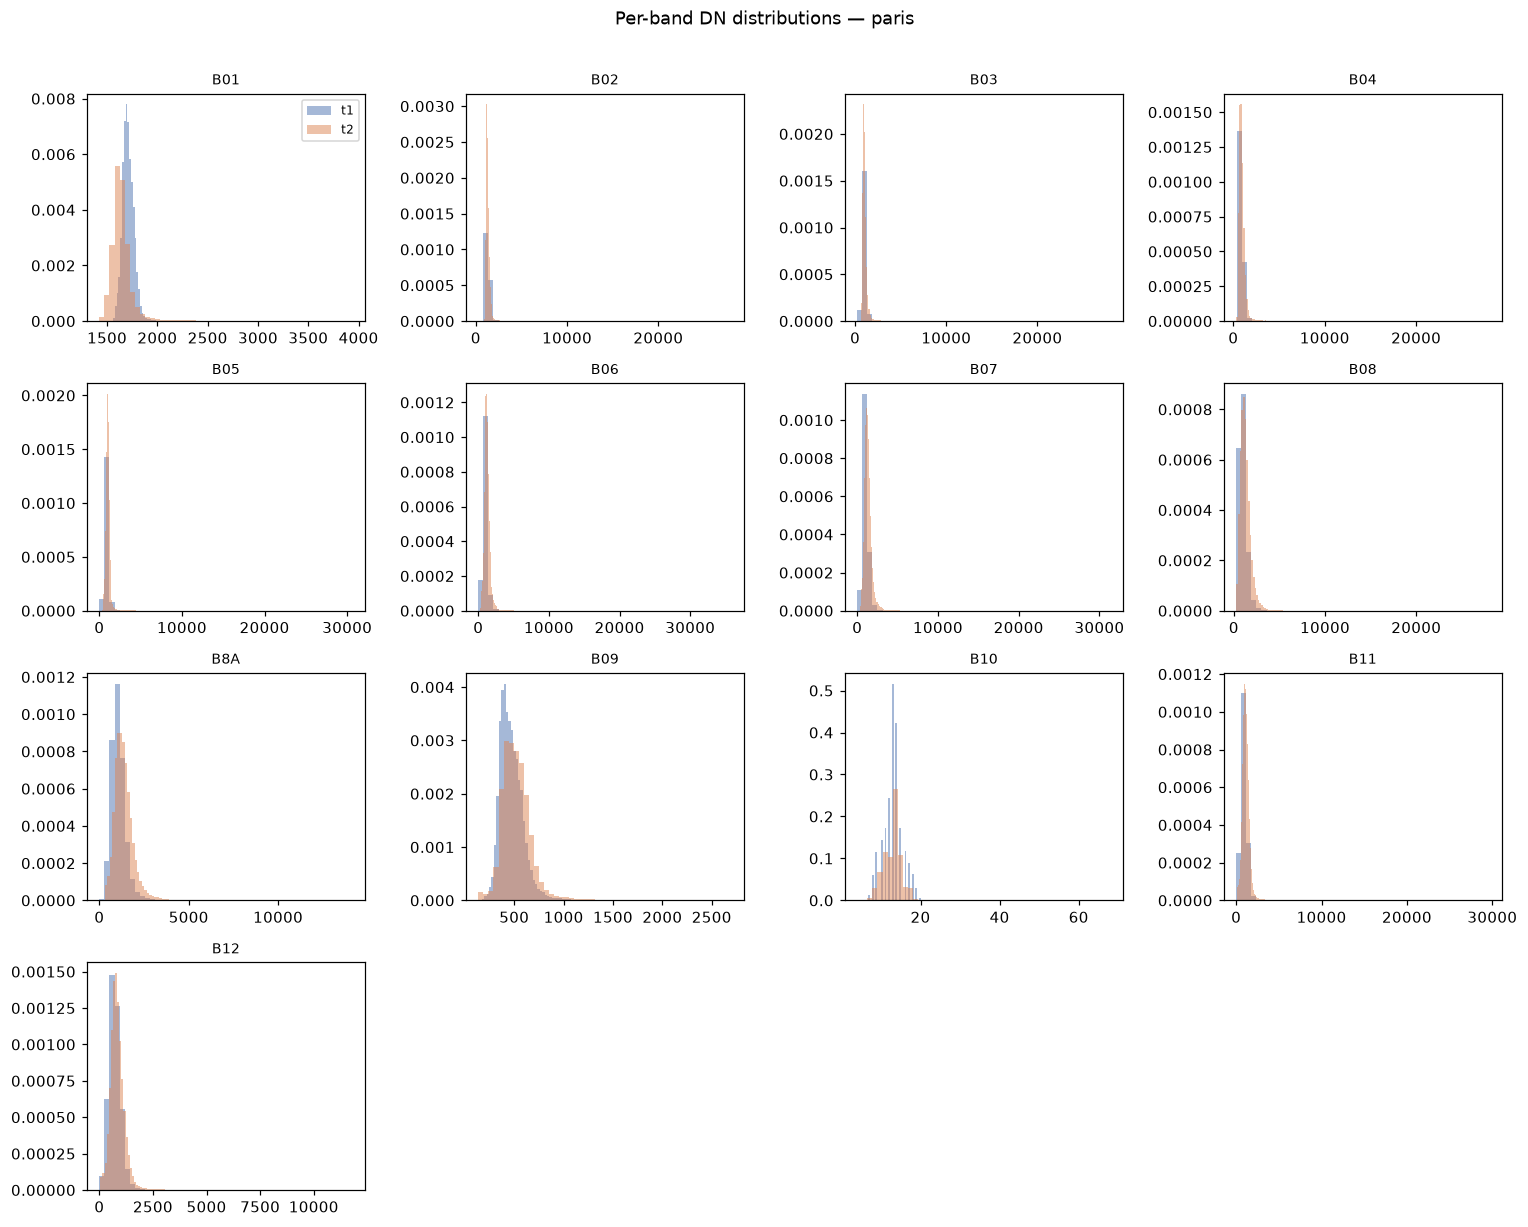

In [34]:

city = CFG["sample_city"]
t1 = load_rect_stack(city, "imgs_1_rect")
t2 = load_rect_stack(city, "imgs_2_rect")
label = label_to_binary(load_label(city))

fig, axes = plt.subplots(4, 4, figsize=(14, 11))
for i, band in enumerate(BANDS):
    ax = axes.ravel()[i]
    ax.hist(t1[i].ravel(), bins=50, alpha=0.5, label="t1", density=True, color="#4C72B0")
    ax.hist(t2[i].ravel(), bins=50, alpha=0.5, label="t2", density=True, color="#DD8452")
    ax.set_title(band, fontsize=9)
axes.ravel()[0].legend(fontsize=8)
for ax in axes.ravel()[len(BANDS):]:
    ax.axis("off")
fig.suptitle(f"Per-band DN distributions — {city}", y=1.01)
plt.tight_layout(); plt.show()


Profiles: 100%|██████████| 14/14 [00:00<00:00, 29.47it/s]


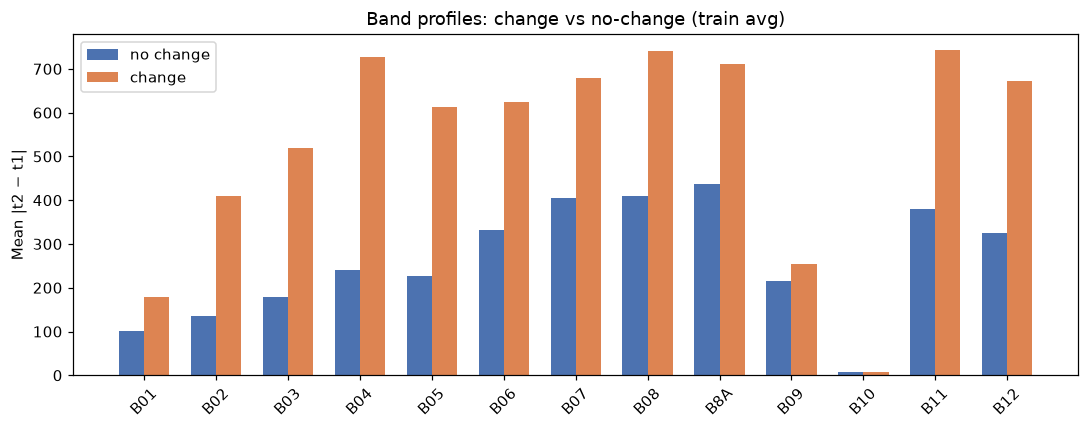

In [35]:

def band_profiles(city: str) -> pd.DataFrame:
    t1 = load_rect_stack(city, "imgs_1_rect")
    t2 = load_rect_stack(city, "imgs_2_rect")
    diff = np.abs(t2 - t1)
    y = label_to_binary(load_label(city))
    rows = []
    for i, band in enumerate(BANDS):
        for cls_name, mask in [("no_change", y == 0), ("change", y == 1)]:
            if not mask.any():
                continue
            rows.append({
                "city": city, "band": band, "class": cls_name,
                "mean_abs_diff": float(diff[i][mask].mean()),
            })
    return pd.DataFrame(rows)

profiles = pd.concat([band_profiles(c) for c in tqdm(TRAIN_CITIES, desc="Profiles")], ignore_index=True)
profile_agg = profiles.groupby(["band", "class"])["mean_abs_diff"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
width = 0.35
x = np.arange(len(BANDS))
for j, (cls_name, color) in enumerate([("no_change", "#4C72B0"), ("change", "#DD8452")]):
    vals = profile_agg[profile_agg["class"] == cls_name].set_index("band").loc[BANDS]["mean_abs_diff"]
    ax.bar(x + j * width, vals, width, label=cls_name.replace("_", " "), color=color)
ax.set_xticks(x + width / 2, BANDS, rotation=45)
ax.set_ylabel("Mean |t2 − t1|"); ax.set_title("Band profiles: change vs no-change (train avg)")
ax.legend(); plt.tight_layout(); plt.show()


Indices: 100%|██████████| 14/14 [00:00<00:00, 35.60it/s]


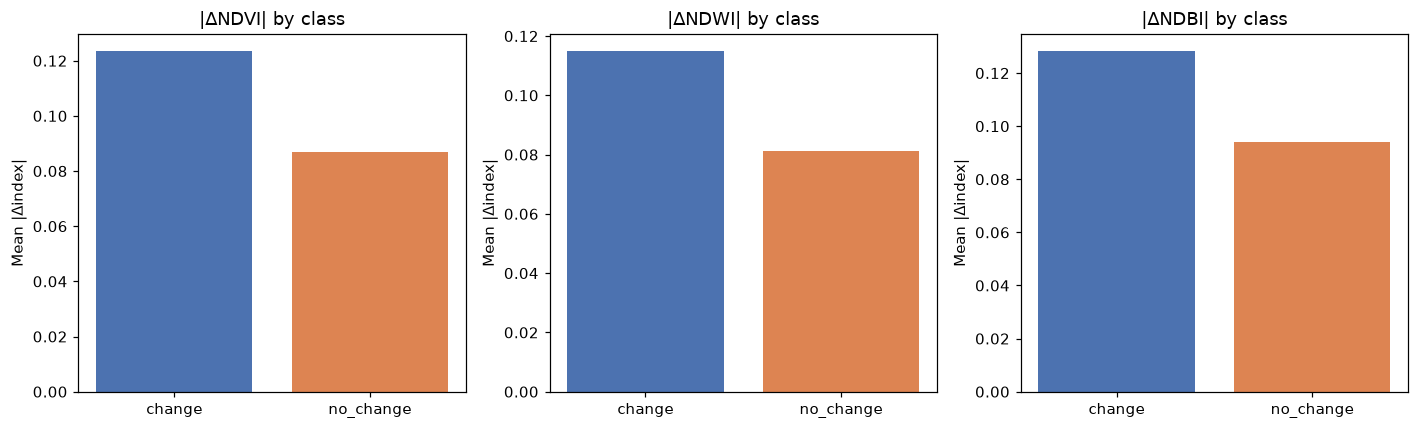

,index,class,mean_delta
0,NDBI,change,0.128240
1,NDBI,no_change,0.093865
2,NDVI,change,0.123460
3,NDVI,no_change,0.086853
4,NDWI,change,0.114893
5,NDWI,no_change,0.081343


In [36]:

index_rows = []
for city in tqdm(TRAIN_CITIES, desc="Indices"):
    t1 = load_rect_stack(city, "imgs_1_rect")
    t2 = load_rect_stack(city, "imgs_2_rect")
    y = label_to_binary(load_label(city))
    bi = {b: band_index(b) for b in ["B03", "B04", "B08", "B11"]}
    indices_t1 = {
        "NDVI": compute_ndvi(t1[bi["B04"]], t1[bi["B08"]]),
        "NDWI": compute_ndwi(t1[bi["B03"]], t1[bi["B08"]]),
        "NDBI": compute_ndbi(t1[bi["B11"]], t1[bi["B08"]]),
    }
    indices_t2 = {
        "NDVI": compute_ndvi(t2[bi["B04"]], t2[bi["B08"]]),
        "NDWI": compute_ndwi(t2[bi["B03"]], t2[bi["B08"]]),
        "NDBI": compute_ndbi(t2[bi["B11"]], t2[bi["B08"]]),
    }
    for idx_name in indices_t1:
        delta = np.abs(indices_t2[idx_name] - indices_t1[idx_name])
        for cls_name, mask in [("no_change", y == 0), ("change", y == 1)]:
            if mask.any():
                index_rows.append({
                    "city": city, "index": idx_name, "class": cls_name,
                    "mean_delta": float(delta[mask].mean()),
                })

index_df = pd.DataFrame(index_rows)
index_agg = index_df.groupby(["index", "class"])["mean_delta"].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, idx_name in zip(axes, ["NDVI", "NDWI", "NDBI"]):
    sub = index_agg[index_agg["index"] == idx_name]
    ax.bar(sub["class"], sub["mean_delta"], color=["#4C72B0", "#DD8452"])
    ax.set_title(f"|Δ{idx_name}| by class"); ax.set_ylabel("Mean |Δindex|")
plt.tight_layout(); plt.show()
index_agg


## 5. Class balance

Change detection is heavily imbalanced — most pixels are unchanged.

In [37]:

balance_rows = []
for city in TRAIN_CITIES:
    y = label_to_binary(load_label(city))
    n_change = int(y.sum())
    n_total = y.size
    balance_rows.append({
        "city": city, "n_pixels": n_total, "n_change": n_change,
        "n_no_change": n_total - n_change,
        "change_pct": 100.0 * n_change / n_total,
        "imbalance_ratio": (n_total - n_change) / max(n_change, 1),
    })
balance_df = pd.DataFrame(balance_rows).sort_values("change_pct", ascending=False)
total_change = balance_df["n_change"].sum()
total_pixels = balance_df["n_pixels"].sum()
print(f"Global change rate: {100*total_change/total_pixels:.3f}%")
print(f"Imbalance ratio  : {(total_pixels-total_change)/total_change:.1f} : 1")
balance_df


Global change rate: 2.289%
Imbalance ratio  : 42.7 : 1


,city,n_pixels,n_change,n_no_change,change_pct,imbalance_ratio
7,abudhabi,627215,23592,603623,3.761390,25.585919
11,hongkong,375300,13379,361921,3.564881,27.051424
12,beirut,1262600,33918,1228682,2.686361,36.225072
5,rennes,190857,4932,185925,2.584134,37.697689
13,mumbai,477906,12244,465662,2.562010,38.031852
10,beihai,696344,17318,679026,2.486989,39.209262
8,cupertino,799820,18942,780878,2.368283,41.224686
0,aguasclaras,247275,4056,243219,1.640279,59.965237
9,pisa,557168,9130,548038,1.638644,60.026068
3,nantes,303804,3449,300355,1.135271,87.084662


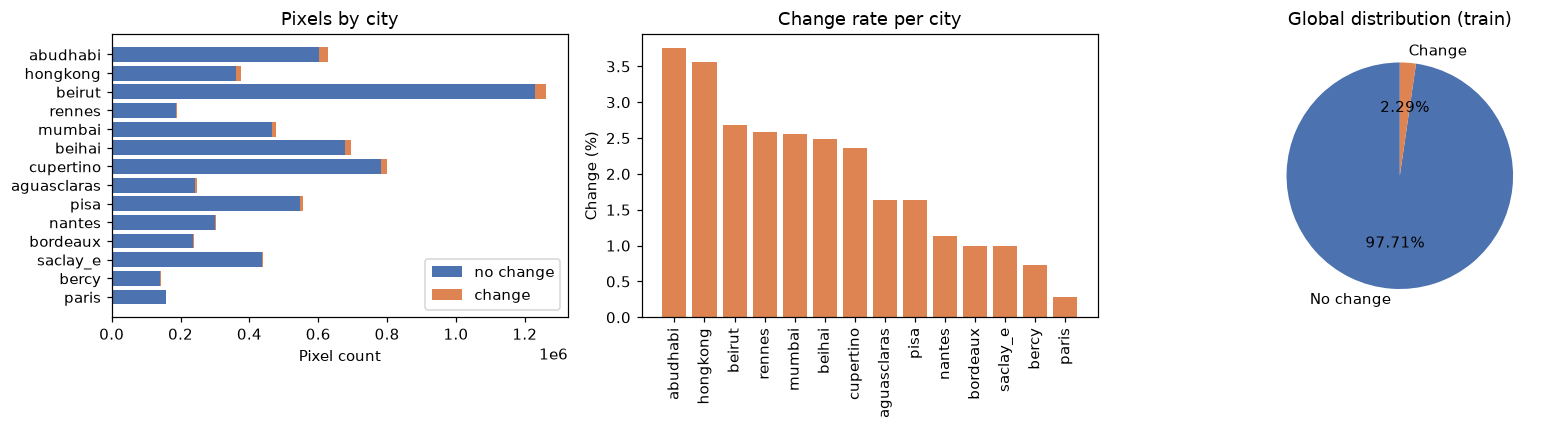

In [38]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cities_sorted = balance_df.sort_values("change_pct")["city"]
bottom = np.zeros(len(cities_sorted))
for col, color, lbl in [("n_no_change", "#4C72B0", "no change"), ("n_change", "#DD8452", "change")]:
    vals = balance_df.set_index("city").loc[cities_sorted][col]
    axes[0].barh(cities_sorted, vals, left=bottom, label=lbl, color=color)
    bottom += vals.values
axes[0].set_xlabel("Pixel count"); axes[0].set_title("Pixels by city"); axes[0].legend()
axes[1].bar(balance_df["city"], balance_df["change_pct"], color="#DD8452")
axes[1].set_ylabel("Change (%)"); axes[1].set_title("Change rate per city")
axes[1].tick_params(axis="x", rotation=90)
axes[2].pie([total_pixels - total_change, total_change], labels=["No change", "Change"],
            autopct="%1.2f%%", colors=["#4C72B0", "#DD8452"], startangle=90)
axes[2].set_title("Global distribution (train)")
plt.tight_layout(); plt.show()


## 6. Feature importance

Point-biserial r, mutual information, and Random Forest on stratified pixel subsamples.

In [39]:

X_parts, y_parts = [], []
for city in tqdm(TRAIN_CITIES, desc="Feature matrix"):
    X, y = build_pixel_features(city)
    Xs, ys = stratified_subsample(X, y, CFG["pixels_per_class"], seed=CFG["random_seed"])
    X_parts.append(Xs)
    y_parts.append(ys)

X_all = np.vstack(X_parts)
y_all = np.concatenate(y_parts)
print(f"Subsample: {len(y_all):,} pixels | change rate = {y_all.mean():.3f}")

corr_vals = [stats.pointbiserialr(y_all, X_all[:, i]).statistic for i in range(X_all.shape[1])]
mi_vals = mutual_info_classif(X_all, y_all, discrete_features=False, random_state=CFG["random_seed"])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.25, stratify=y_all, random_state=CFG["random_seed"]
)
rf = RandomForestClassifier(
    n_estimators=CFG["rf_estimators"], max_depth=12,
    class_weight="balanced", random_state=CFG["random_seed"], n_jobs=-1,
)
rf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, rf.predict_proba(X_te)[:, 1])
print(f"Random Forest ROC-AUC (hold-out): {auc:.3f}")

importance_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "point_biserial_r": corr_vals,
    "mutual_info": mi_vals,
    "rf_importance": rf.feature_importances_,
}).sort_values("rf_importance", ascending=False)
importance_df


Feature matrix: 100%|██████████| 14/14 [00:00<00:00, 33.06it/s]


Subsample: 78,884 pixels | change rate = 0.468
Random Forest ROC-AUC (hold-out): 0.882


,feature,point_biserial_r,mutual_info,rf_importance
3,|ΔB04|,0.433603,0.139157,0.194467
4,|ΔB05|,0.413174,0.126672,0.154037
2,|ΔB03|,0.384121,0.118476,0.114548
1,|ΔB02|,0.350113,0.113206,0.107759
12,|ΔB12|,0.321241,0.071994,0.062570
0,|ΔB01|,0.268346,0.056417,0.057788
9,|ΔB09|,0.115703,0.014099,0.051054
11,|ΔB11|,0.309673,0.061105,0.048222
10,|ΔB10|,-0.067808,0.009295,0.038798
5,|ΔB06|,0.297866,0.055175,0.029592


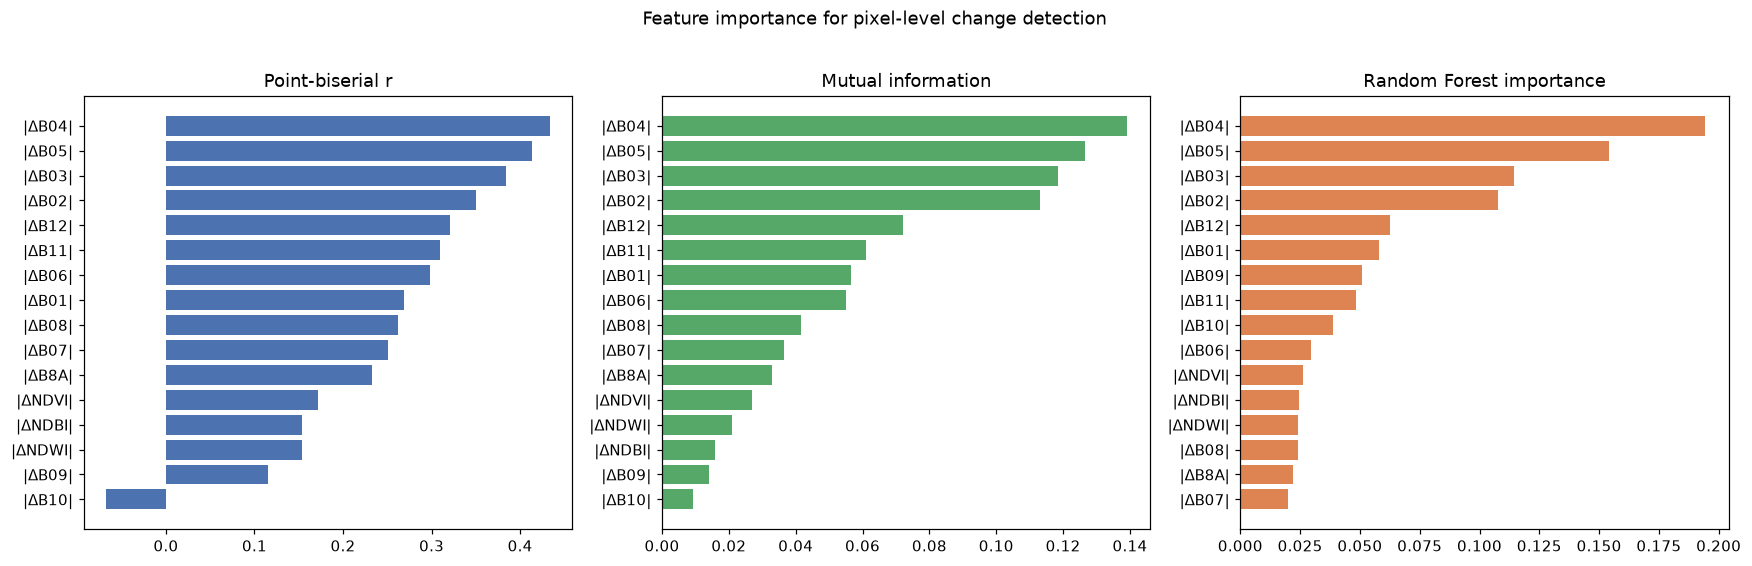

In [40]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, title, color) in zip(axes, [
    ("point_biserial_r", "Point-biserial r", "#4C72B0"),
    ("mutual_info", "Mutual information", "#55A868"),
    ("rf_importance", "Random Forest importance", "#DD8452"),
]):
    sub = importance_df.sort_values(col, ascending=True)
    ax.barh(sub["feature"], sub[col], color=color)
    ax.set_title(title)
plt.suptitle("Feature importance for pixel-level change detection", y=1.02)
plt.tight_layout(); plt.show()


## 7. Visual samples & spatial patches

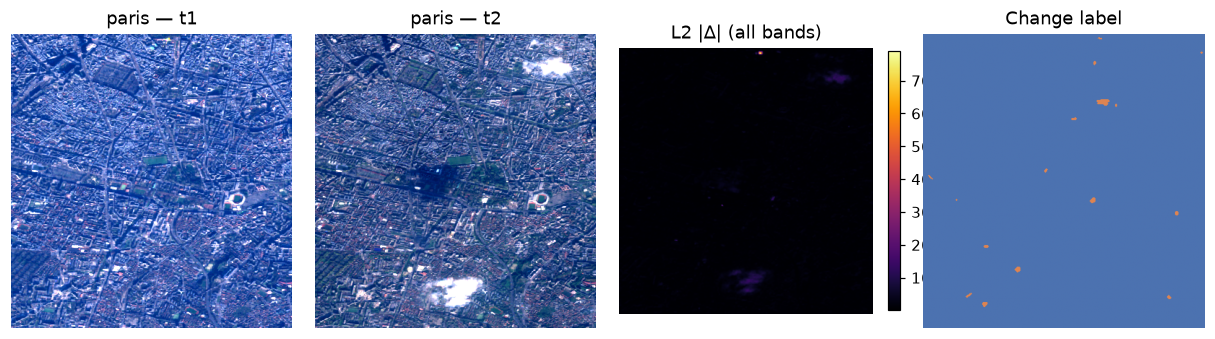

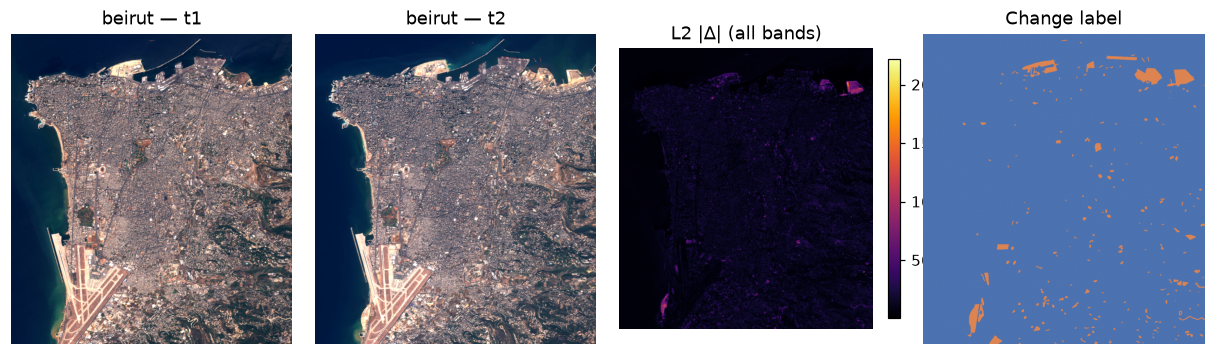

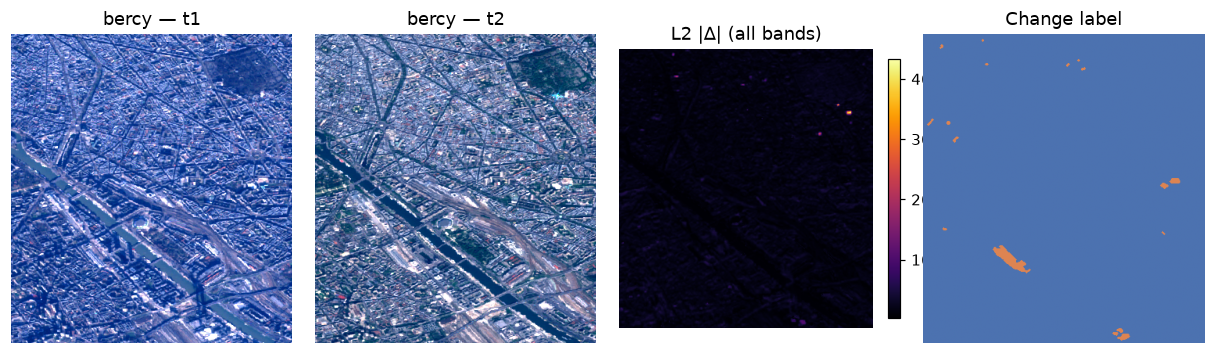

In [41]:

def show_city_panel(city: str):
    t1 = load_rect_stack(city, "imgs_1_rect")
    t2 = load_rect_stack(city, "imgs_2_rect")
    diff_mag = np.linalg.norm(t2 - t1, axis=0)
    has_label = city in TRAIN_CITIES
    label = label_to_binary(load_label(city)) if has_label else None

    ncols = 4 if has_label else 3
    fig = plt.figure(figsize=(3.5 * ncols, 4))
    gs = gridspec.GridSpec(1, ncols, wspace=0.08)
    ax0 = fig.add_subplot(gs[0]); ax0.imshow(normalize_rgb(t1)); ax0.set_title(f"{city} — t1"); ax0.axis("off")
    ax1 = fig.add_subplot(gs[1]); ax1.imshow(normalize_rgb(t2)); ax1.set_title(f"{city} — t2"); ax1.axis("off")
    ax2 = fig.add_subplot(gs[2]); im = ax2.imshow(diff_mag, cmap="inferno")
    ax2.set_title("L2 |Δ| (all bands)"); ax2.axis("off"); plt.colorbar(im, ax=ax2, fraction=0.046)
    if has_label:
        ax3 = fig.add_subplot(gs[3])
        ax3.imshow(label, cmap=ListedColormap(["#4C72B0", "#DD8452"]), vmin=0, vmax=1)
        ax3.set_title("Change label"); ax3.axis("off")
    plt.show()

for city in CFG["visual_cities"]:
    show_city_panel(city)


Change patches: 100%|██████████| 14/14 [00:00<00:00, 57.55it/s]


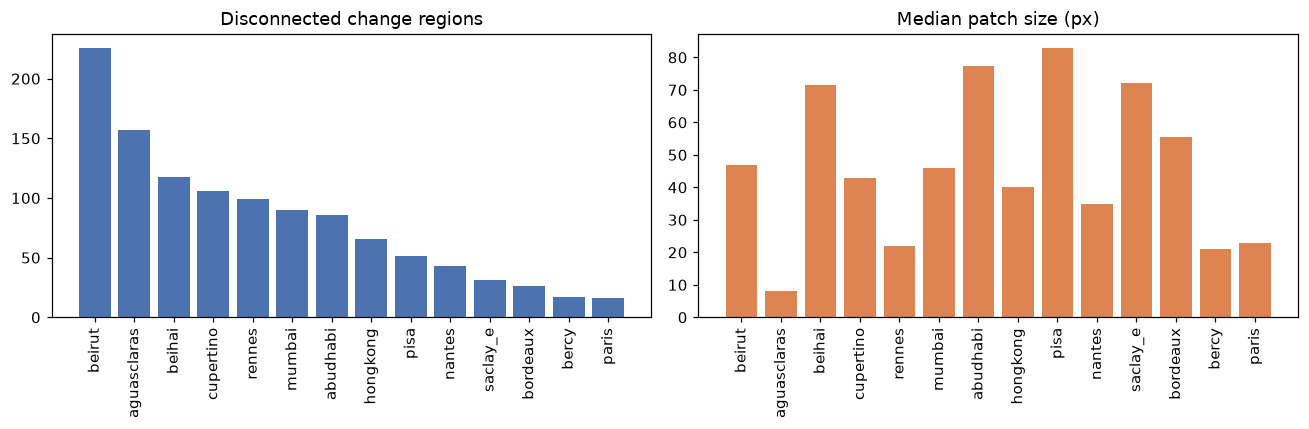

,city,n_change_regions,mean_patch_size,median_patch_size,max_patch_size
12,beirut,226,150.079646,47.0,4200
0,aguasclaras,157,25.834395,8.0,884
10,beihai,118,146.762712,71.5,2347
8,cupertino,106,178.698113,43.0,5872
5,rennes,99,49.818182,22.0,713


In [42]:

cc_rows = []
for city in tqdm(TRAIN_CITIES, desc="Change patches"):
    y = label_to_binary(load_label(city))
    labeled, n_components = cc_label(y)
    sizes = [int((labeled == i).sum()) for i in range(1, n_components + 1)]
    cc_rows.append({
        "city": city,
        "n_change_regions": n_components,
        "mean_patch_size": float(np.mean(sizes)) if sizes else 0.0,
        "median_patch_size": float(np.median(sizes)) if sizes else 0.0,
        "max_patch_size": max(sizes) if sizes else 0,
    })
cc_df = pd.DataFrame(cc_rows).sort_values("n_change_regions", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cc_df["city"], cc_df["n_change_regions"], color="#4C72B0")
axes[0].set_title("Disconnected change regions"); axes[0].tick_params(axis="x", rotation=90)
axes[1].bar(cc_df["city"], cc_df["median_patch_size"], color="#DD8452")
axes[1].set_title("Median patch size (px)"); axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()
cc_df.head()


## 8. Interpretation → feature engineering & selection roadmap

Synthesizes all EDA outputs above into actionable next steps.

In [43]:

def interpret_eda_findings() -> dict:
    global_change_pct = 100.0 * balance_df["n_change"].sum() / balance_df["n_pixels"].sum()
    worst = balance_df.loc[balance_df["imbalance_ratio"].idxmax()]
    top_feats = rank_consensus(importance_df, top_k=6)

    pivot = profile_agg.pivot(index="band", columns="class", values="mean_abs_diff")
    pivot["separation_ratio"] = pivot["change"] / pivot["no_change"].replace(0, np.nan)
    best_bands = pivot.sort_values("separation_ratio", ascending=False).head(5)

    idx_pivot = index_agg.pivot(index="index", columns="class", values="mean_delta")
    idx_pivot["separation_ratio"] = idx_pivot["change"] / idx_pivot["no_change"].replace(0, np.nan)

    high_corr_pairs = [
        (BANDS[i], BANDS[j], corr_matrix[i, j])
        for i in range(len(BANDS)) for j in range(i + 1, len(BANDS))
        if abs(corr_matrix[i, j]) >= 0.85
    ]

    meaning = {
        "Class imbalance": (
            f"Only ~{global_change_pct:.2f}% of labelled pixels are change. "
            f"Worst: {worst['city']} ({worst['change_pct']:.2f}%, {worst['imbalance_ratio']:.0f}:1). "
            "Models will bias to no-change unless rebalanced."
        ),
        "Feature signal": (
            f"|Δband| features give ROC-AUC ≈ {auc:.2f} with a simple RF. "
            f"Top features: {', '.join(top_feats['feature'].tolist())}."
        ),
        "Band behavior": (
            f"Largest change/no-change separation in {', '.join(best_bands.index[:3].tolist())}."
        ),
        "Indices": ", ".join(
            f"{idx} ratio={idx_pivot.loc[idx, 'separation_ratio']:.2f}" for idx in idx_pivot.index
        ),
        "Redundancy": (
            f"{len(high_corr_pairs)} band-|Δ| pairs with |r|≥0.85"
            + (f" (e.g. {high_corr_pairs[0][0]}↔{high_corr_pairs[0][1]})" if high_corr_pairs else "")
        ),
        "Spatial context": (
            f"Median {cc_df['n_change_regions'].median():.0f} regions/scene, "
            f"median patch {cc_df['median_patch_size'].median():.0f} px — add neighborhood features."
        ),
    }

    return {
        "meaning": meaning,
        "feature_engineering_todos": [
            "Keep |Δband|; add signed Δ and log-ratio (t2/t1) for illumination robustness.",
            "Expand indices (EVI, SAVI, NBR); keep t1, t2, Δ separately.",
            "Add 3×3 / 5×5 neighborhood |Δ| stats and SWIR/NIR texture (GLCM).",
            "Per-city radiometric normalization before differencing.",
            "Interaction terms: ΔB11 × ΔNDBI for built-up change.",
        ],
        "feature_selection_todos": [
            f"Start with consensus top-6: {', '.join(top_feats['feature'].tolist())}.",
            "Drop low-importance bands (often B01, B09, B10).",
            "Prune one band from each correlated pair (|r|≥0.85).",
            "Ablation: top-5 |Δ| vs indices-only vs combined; metric = change F1.",
            "Use stratified CV — accuracy is misleading at ~98:2 imbalance.",
        ],
        "modelling_todos": [
            "Focal loss / oversampling; optimize change-class F1 or PR-AUC.",
            "Post-process: remove components smaller than median patch size.",
            "Use imgs_*_rect for unified 10 m grid.",
        ],
        "top_features": top_feats,
    }


results = interpret_eda_findings()
print("=" * 70 + "\nWHAT THE RESULTS MEAN\n" + "=" * 70)
for title, text in results["meaning"].items():
    print(f"\n▸ {title}\n  {text}")
for section, key in [("FEATURE ENGINEERING", "feature_engineering_todos"),
                     ("FEATURE SELECTION", "feature_selection_todos"),
                     ("MODELLING", "modelling_todos")]:
    print(f"\n{'=' * 70}\nNEXT TODO — {section}\n{'=' * 70}")
    for i, todo in enumerate(results[key], 1):
        print(f"  {i}. {todo}")
results["top_features"]


WHAT THE RESULTS MEAN

▸ Class imbalance
  Only ~2.29% of labelled pixels are change. Worst: paris (0.29%, 346:1). Models will bias to no-change unless rebalanced.

▸ Feature signal
  |Δband| features give ROC-AUC ≈ 0.88 with a simple RF. Top features: |ΔB04|, |ΔB05|, |ΔB03|, |ΔB02|, |ΔB12|, |ΔB11|.

▸ Band behavior
  Largest change/no-change separation in B02, B04, B03.

▸ Indices
  NDBI ratio=1.37, NDVI ratio=1.42, NDWI ratio=1.41

▸ Redundancy
  6 band-|Δ| pairs with |r|≥0.85 (e.g. B02↔B03)

▸ Spatial context
  Median 76 regions/scene, median patch 44 px — add neighborhood features.

NEXT TODO — FEATURE ENGINEERING
  1. Keep |Δband|; add signed Δ and log-ratio (t2/t1) for illumination robustness.
  2. Expand indices (EVI, SAVI, NBR); keep t1, t2, Δ separately.
  3. Add 3×3 / 5×5 neighborhood |Δ| stats and SWIR/NIR texture (GLCM).
  4. Per-city radiometric normalization before differencing.
  5. Interaction terms: ΔB11 × ΔNDBI for built-up change.

NEXT TODO — FEATURE SELECTION
  1. 

,feature,point_biserial_r,mutual_info,rf_importance,point_biserial_r_rank,mutual_info_rank,rf_importance_rank,consensus_rank
3,|ΔB04|,0.433603,0.139157,0.194467,1.0,1.0,1.0,1.000000
4,|ΔB05|,0.413174,0.126672,0.154037,2.0,2.0,2.0,2.000000
2,|ΔB03|,0.384121,0.118476,0.114548,3.0,3.0,3.0,3.000000
1,|ΔB02|,0.350113,0.113206,0.107759,4.0,4.0,4.0,4.000000
12,|ΔB12|,0.321241,0.071994,0.062570,5.0,5.0,5.0,5.000000
11,|ΔB11|,0.309673,0.061105,0.048222,6.0,6.0,8.0,6.666667


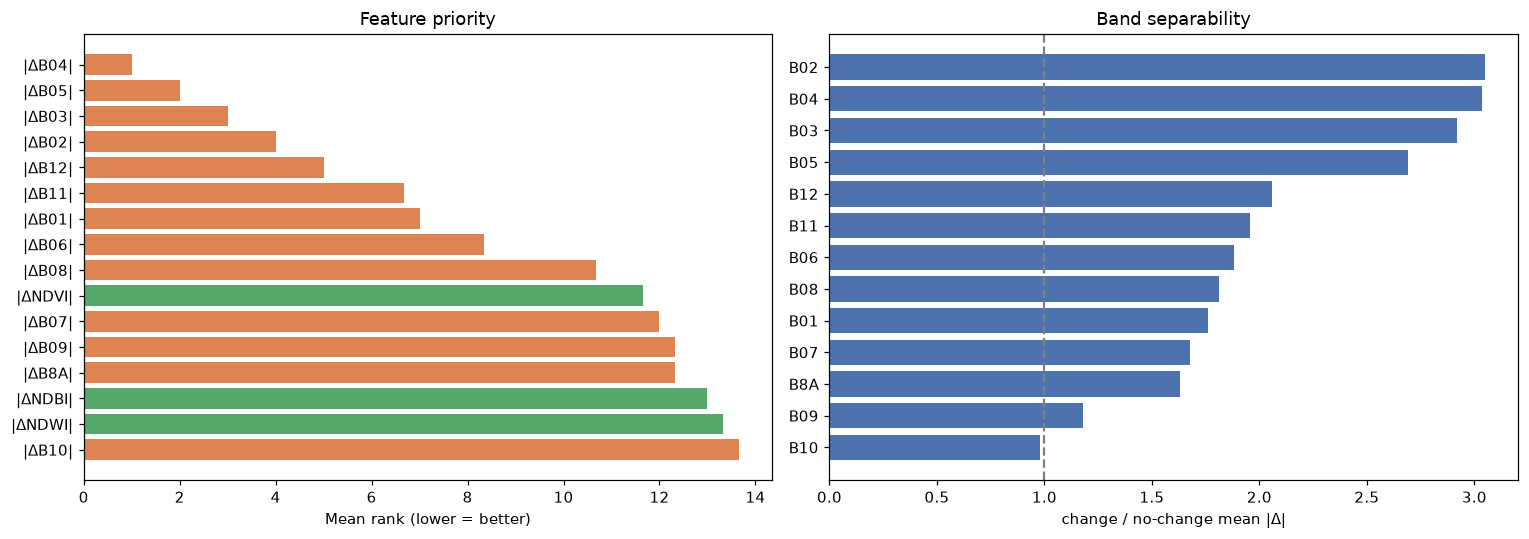

In [44]:

consensus = importance_df.copy()
for col in ["point_biserial_r", "mutual_info", "rf_importance"]:
    consensus[f"{col}_rank"] = consensus[col].rank(ascending=False)
consensus["consensus_rank"] = consensus[[
    "point_biserial_r_rank", "mutual_info_rank", "rf_importance_rank"
]].mean(axis=1)
consensus = consensus.sort_values("consensus_rank")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#DD8452" if f.startswith("|ΔB") else "#55A868" for f in consensus["feature"]]
axes[0].barh(consensus["feature"], consensus["consensus_rank"], color=colors)
axes[0].set_xlabel("Mean rank (lower = better)"); axes[0].set_title("Feature priority")
axes[0].invert_yaxis()

pivot = profile_agg.pivot(index="band", columns="class", values="mean_abs_diff").loc[BANDS]
pivot["ratio"] = pivot["change"] / pivot["no_change"]
pivot = pivot.sort_values("ratio")
axes[1].barh(pivot.index, pivot["ratio"], color="#4C72B0")
axes[1].axvline(1.0, color="gray", ls="--")
axes[1].set_xlabel("change / no-change mean |Δ|"); axes[1].set_title("Band separability")
plt.tight_layout(); plt.show()


## 9. Key takeaways

| Finding | Detail |
|---------|--------|
| **Resolution** | Native 10/20/60 m bands → `*_rect` unifies to 10 m (upsample ×4 or ×36). |
| **Imbalance** | ~2% change globally — evaluate change F1 / PR, not accuracy. |
| **Core signal** | Temporal contrast (|Δband|, Δindices) beats raw reflectance. |
| **Top bands** | SWIR / NIR / red-edge |Δ| rank highest. |
| **Indices** | NDBI & NDVI deltas add complementary signal. |
| **Redundancy** | Correlated band-|Δ| pairs → prune before linear models. |
| **Spatial** | Small fragmented patches → neighborhood features + post-processing. |

**Next step:** signed/ratio diffs + expanded indices + local context → ablation under class-balanced CV.
